<h1>Линейные модели, SVM и деревья решений.</h1>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
%matplotlib inline 
sns.set(style="ticks")
data = pd.read_csv('credit_card_frauds.csv', sep=",")

data.head(5)

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [2]:
print(data.isnull().sum())

data_cleaned = data.dropna()

print(f"\nРазмер данных до очистки: {data.shape}")
print(f"Размер данных после очистки: {data_cleaned.shape}")

data_cleaned = data.drop(["trans_num", "merch_lat", "merch_long"], axis=1)

print(f"\nУникальные значения в столбцах до очистки: {data.nunique()}")
print(f"\nУникальные значения в столбцах до очистки: {data_cleaned.nunique()}")

data = data_cleaned

data.head(5)

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Размер данных до очистки: (339607, 15)
Размер данных после очистки: (339607, 15)

Уникальные значения в столбцах до очистки: trans_date_trans_time    338504
merchant                    693
category                     14
amt                       32112
city                        176
state                        13
lat                         183
long                        183
city_pop                    174
job                         163
dob                         187
trans_num                339607
merch_lat                335608
merch_long               337263
is_fraud

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,0


In [3]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['trans_hour'] = data['trans_date_trans_time'].dt.hour
data['trans_day'] = data['trans_date_trans_time'].dt.day
data['trans_month'] = data['trans_date_trans_time'].dt.month
data['trans_dayofweek'] = data['trans_date_trans_time'].dt.dayofweek

data['dob'] = pd.to_datetime(data['dob'])
data = data.drop(['trans_date_trans_time', 'dob'], axis=1)

categorical_columns = ['merchant', 'category', 'city', 'state', 'job']

for col in categorical_columns:
    print(f"{col}: {data[col].nunique()}")

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

data.head(5)

merchant: 693
category: 14
city: 176
state: 13
job: 163


,merchant,category,amt,city,state,lat,long,city_pop,job,is_fraud,trans_hour,trans_day,trans_month,trans_dayofweek
0,241,4,107.23,116,11,48.8878,-118.2105,149,139,0,0,1,1,1
1,390,0,220.11,93,5,42.1808,-112.2620,4154,101,0,0,1,1,1
2,308,4,96.29,51,2,41.6125,-122.5258,589,143,0,0,1,1,1
3,42,12,7.77,55,8,32.9396,-105.8189,899,102,0,0,1,1,1
4,82,9,6.85,46,12,43.0172,-111.0292,471,45,0,0,1,1,1


In [4]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {train_data.shape}")
print(f"Размер тестовой выборки: {test_data.shape}")

Размер обучающей выборки: (237724, 14)
Размер тестовой выборки: (101883, 14)


Распределение классов в обучающей выборке:
is_fraud
0    0.994792
1    0.005208
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
is_fraud
0    0.994661
1    0.005339
Name: proportion, dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    101339
           1       0.06      0.75      0.12       544

    accuracy                           0.94    101883
   macro avg       0.53      0.85      0.54    101883
weighted avg       0.99      0.94      0.96    101883

ROC-AUC Score: 0.8608


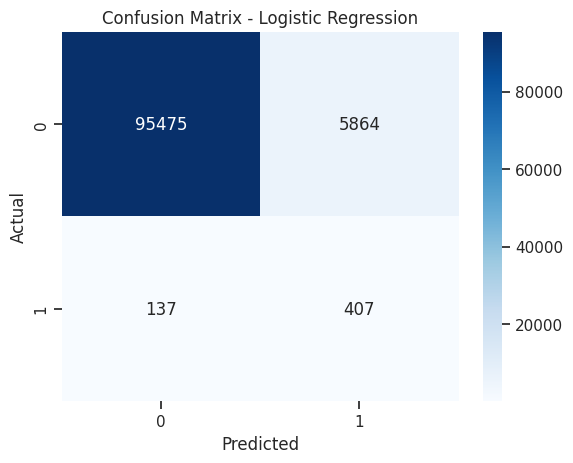


Classification Report (LinearSVC):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    101339
           1       0.08      0.71      0.15       544

    accuracy                           0.96    101883
   macro avg       0.54      0.83      0.56    101883
weighted avg       0.99      0.96      0.97    101883

ROC-AUC Score: 0.8676


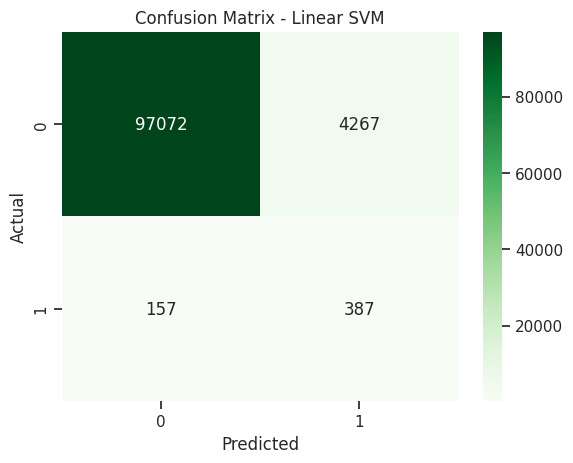


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    101339
           1       0.23      0.91      0.36       544

    accuracy                           0.98    101883
   macro avg       0.61      0.94      0.68    101883
weighted avg       1.00      0.98      0.99    101883

ROC-AUC Score: 0.9531


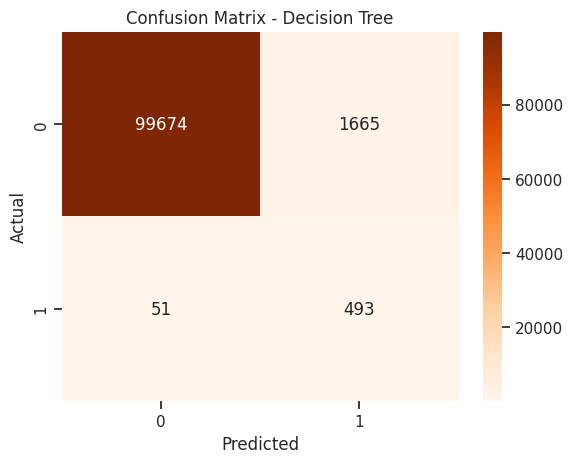

In [5]:
target_column = 'is_fraud'

X_train = train_data.drop(target_column, axis=1)
y_train = train_data[target_column]
X_test = test_data.drop(target_column, axis=1)
y_test = test_data[target_column]

print("Распределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_log):.4f}")

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. SVM (SUPPORT VECTOR MACHINE)
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
    dual='auto'
)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("\nClassification Report (LinearSVC):")
print(classification_report(y_test, y_pred_svm))

y_decision = svm_model.decision_function(X_test_scaled)
from sklearn.preprocessing import MinMaxScaler
scaler_prob = MinMaxScaler()
y_pred_proba_svm = scaler_prob.fit_transform(y_decision.reshape(-1, 1)).ravel()

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. ДЕРЕВО РЕШЕНИЙ
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10
)
tree_model.fit(X_train_scaled, y_train)

y_pred_tree = tree_model.predict(X_test_scaled)
y_pred_proba_tree = tree_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tree):.4f}")

cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



Топ-10 наиболее важных признаков (Decision Tree):
        feature  importance
2           amt    0.706216
1      category    0.129413
9    trans_hour    0.125030
7      city_pop    0.007666
6          long    0.006154
8           job    0.005820
11  trans_month    0.004622
3          city    0.004399
0      merchant    0.003716
4         state    0.003516


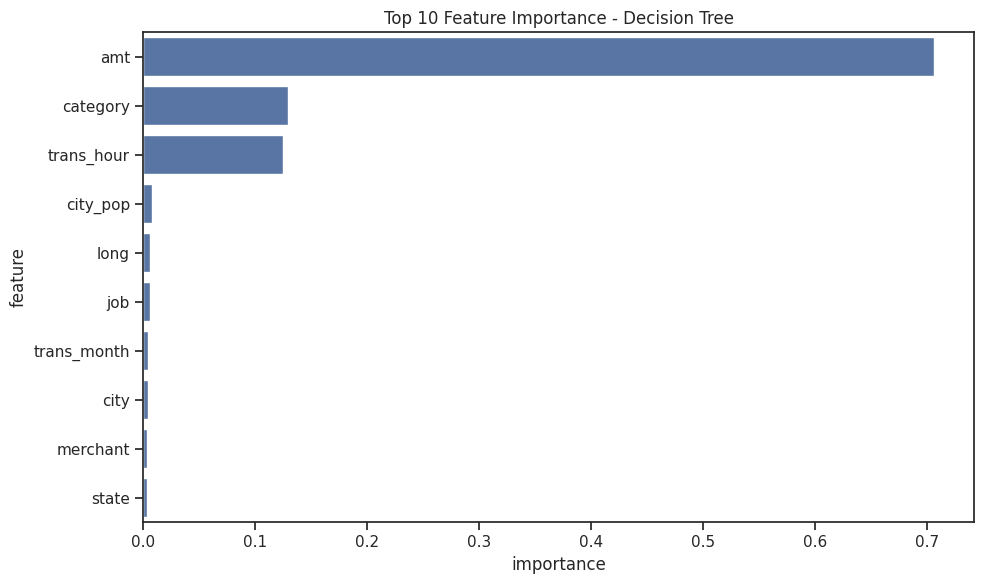


Сравнительная таблица метрик:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9411     0.0649  0.7482    0.1194
Linear SVM             0.9566     0.0832  0.7114    0.1489
Decision Tree          0.9832     0.2285  0.9062    0.3649


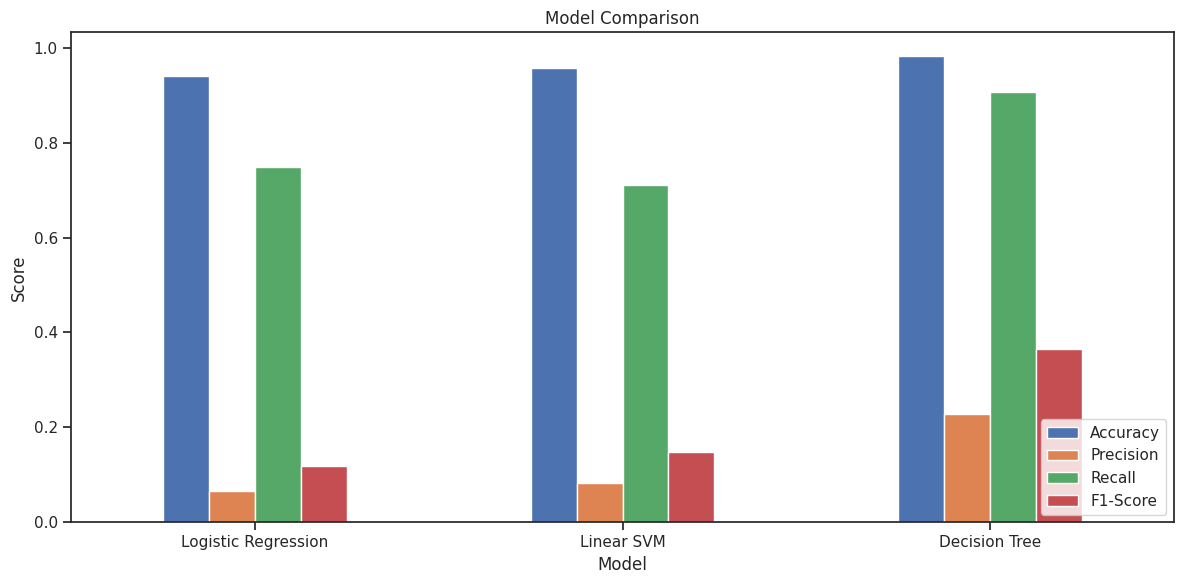

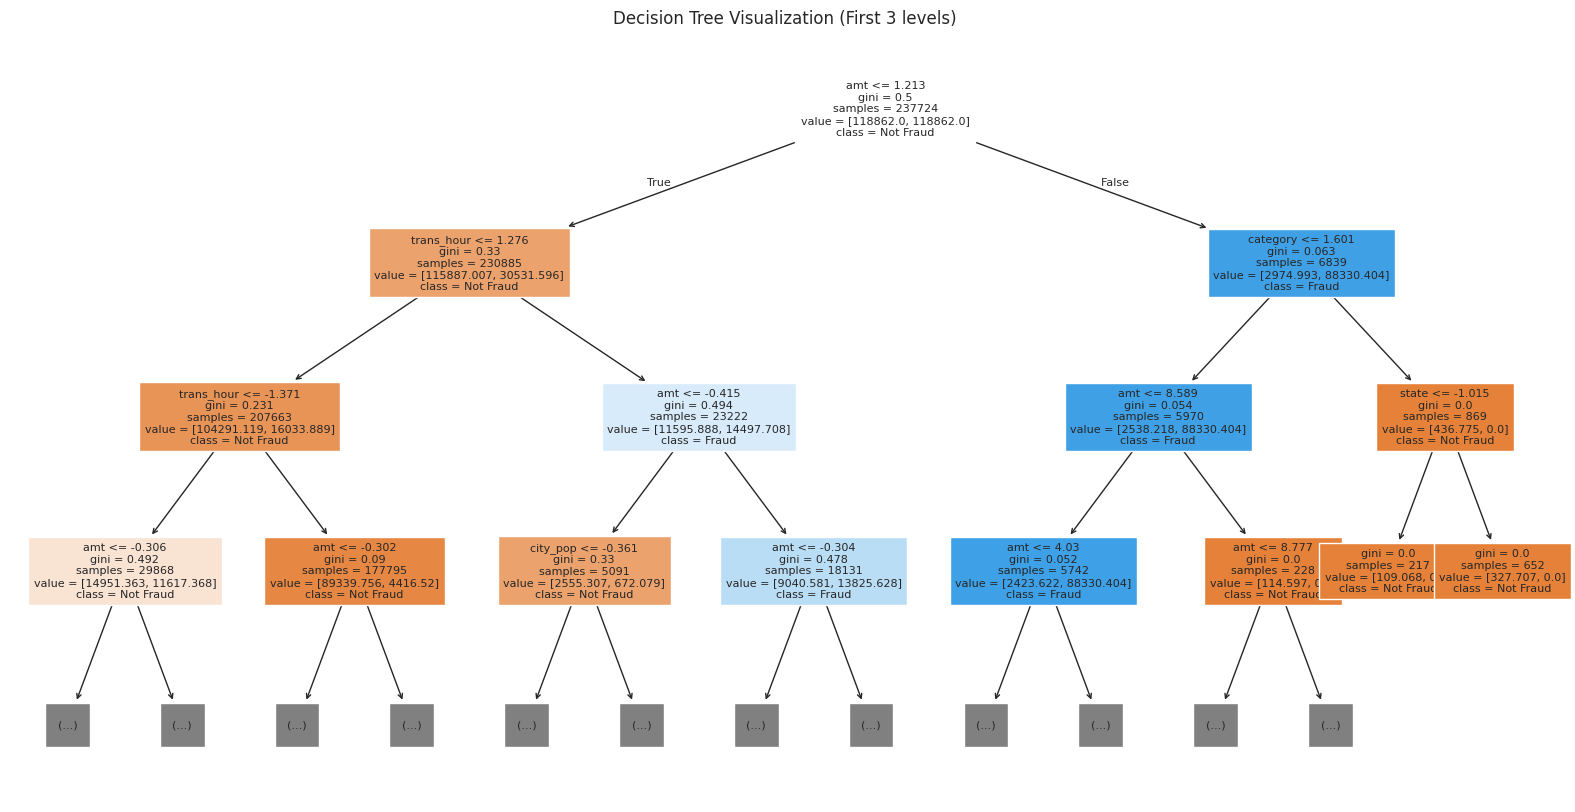

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 наиболее важных признаков (Decision Tree):")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()

models = {
    'Logistic Regression': y_pred_log,
    'Linear SVM': y_pred_svm,
    'Decision Tree': y_pred_tree
}

comparison = pd.DataFrame()
for name, pred in models.items():
    comparison.loc[name, 'Accuracy'] = accuracy_score(y_test, pred)
    comparison.loc[name, 'Precision'] = precision_score(y_test, pred)
    comparison.loc[name, 'Recall'] = recall_score(y_test, pred)
    comparison.loc[name, 'F1-Score'] = f1_score(y_test, pred)

print("\nСравнительная таблица метрик:")
print(comparison.round(4))

comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=X_train.columns, 
          class_names=['Not Fraud', 'Fraud'],
          filled=True, 
          max_depth=3,
          fontsize=8)
plt.title('Decision Tree Visualization (First 3 levels)')
plt.show()